# [Tarea 08] Ejercicios Unidad 03-C mínimos cuadrados
### Damian Aguilar

In [19]:

import numpy as np
import matplotlib.pyplot as plt

OUTDIR = "graficas"
import os
os.makedirs(OUTDIR, exist_ok=True)

def ajuste_polinomial(x, y, grado):
    """Devuelve los coeficientes [a0, a1, ..., a_grado] del polinomio
    P(x) = a0 + a1*x + ... + a_grado*x^grado que minimiza el error
    cuadrático, resolviendo el sistema normal de mínimos cuadrados."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = grado + 1
    # Matriz de diseño (Vandermonde): columnas 1, x, x^2, ..., x^grado
    A = np.vstack([x**k for k in range(n)]).T
    # Sistema normal: (A^T A) a = A^T y
    ATA = A.T @ A
    ATy = A.T @ y
    coef = np.linalg.solve(ATA, ATy)
    return coef


def evaluar_polinomio(coef, x):
    x = np.asarray(x, dtype=float)
    return sum(c * x**k for k, c in enumerate(coef))


def error_cuadratico(y, y_pred):
    return float(np.sum((np.asarray(y) - np.asarray(y_pred)) ** 2))


def ajuste_exponencial(x, y):
    """Ajusta y = b * e^(a x) linealizando: ln(y) = ln(b) + a*x
    Se hace una regresión lineal de ln(y) contra x."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.log(y)
    coef = ajuste_polinomial(x, z, 1)   # coef = [ln(b), a]
    ln_b, a = coef
    b = np.exp(ln_b)
    return a, b


def evaluar_exponencial(a, b, x):
    return b * np.exp(a * np.asarray(x, dtype=float))


def ajuste_potencia(x, y):
    """Ajusta y = b * x^a linealizando: ln(y) = ln(b) + a*ln(x)"""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    zx = np.log(x)
    zy = np.log(y)
    coef = ajuste_polinomial(zx, zy, 1)  # coef = [ln(b), a]
    ln_b, a = coef
    b = np.exp(ln_b)
    return a, b


def evaluar_potencia(a, b, x):
    return b * np.asarray(x, dtype=float) ** a


def texto_polinomio(coef):
    """Da formato tipo texto: a0 + a1 x + a2 x^2 ..."""
    terms = []
    for k, c in enumerate(coef):
        if k == 0:
            terms.append(f"{c:.6f}")
        elif k == 1:
            terms.append(f"{c:+.6f}·x")
        else:
            terms.append(f"{c:+.6f}·x^{k}")
    return " ".join(terms)




1. Dados los datos:

xi 4.0 4.2 4.5 4.7 5.1 5.5 5.9 6.3 6.8 7.1
yi 102.56 130.11 113.18 142.05 167.53 195.14 224.87 256.73 299.50 326.72

a. Construya el polinomio por mínimos cuadrados de grado 1 y calcule el error.

b. Construya el polinomio por mínimos cuadrados de grado 2 y calcule el error.

c. Construya el polinomio por mínimos cuadrados de grado 3 y calcule el error.

d. Construya el polinomio por mínimos cuadrados de la forma 𝑏𝑒^a*x y calcule el error.

e. Construya el polinomio por mínimos cuadrados de la forma 𝑏𝑥^ay calcule el error. 


In [ ]:

def ejercicio1():
    print("=" * 70)
    print("EJERCICIO 1")
    print("=" * 70)
    x = np.array([4.0, 4.2, 4.5, 4.7, 5.1, 5.5, 5.9, 6.3, 6.8, 7.1])
    y = np.array([102.56, 130.11, 113.18, 142.05, 167.53, 195.14,
                  224.87, 256.73, 299.50, 326.72])

    resultados = {}

    # a. grado 1
    c1 = ajuste_polinomial(x, y, 1)
    e1 = error_cuadratico(y, evaluar_polinomio(c1, x))
    print(f"\na) Grado 1: P(x) = {texto_polinomio(c1)}")
    print(f"   Error cuadrático E = {e1:.6f}")
    resultados['g1'] = (c1, e1)

    # b. grado 2
    c2 = ajuste_polinomial(x, y, 2)
    e2 = error_cuadratico(y, evaluar_polinomio(c2, x))
    print(f"\nb) Grado 2: P(x) = {texto_polinomio(c2)}")
    print(f"   Error cuadrático E = {e2:.6f}")
    resultados['g2'] = (c2, e2)

    # c. grado 3
    c3 = ajuste_polinomial(x, y, 3)
    e3 = error_cuadratico(y, evaluar_polinomio(c3, x))
    print(f"\nc) Grado 3: P(x) = {texto_polinomio(c3)}")
    print(f"   Error cuadrático E = {e3:.6f}")
    resultados['g3'] = (c3, e3)

    # d. b*e^(ax)
    a_exp, b_exp = ajuste_exponencial(x, y)
    y_exp = evaluar_exponencial(a_exp, b_exp, x)
    e_exp = error_cuadratico(y, y_exp)
    print(f"\nd) y = b·e^(a·x):  a = {a_exp:.6f}, b = {b_exp:.6f}")
    print(f"   y = {b_exp:.6f}·e^({a_exp:.6f}·x)")
    print(f"   Error cuadrático E = {e_exp:.6f}")
    resultados['exp'] = (a_exp, b_exp, e_exp)

    # e. b*x^a
    a_pow, b_pow = ajuste_potencia(x, y)
    y_pow = evaluar_potencia(a_pow, b_pow, x)
    e_pow = error_cuadratico(y, y_pow)
    print(f"\ne) y = b·x^a:  a = {a_pow:.6f}, b = {b_pow:.6f}")
    print(f"   y = {b_pow:.6f}·x^{a_pow:.6f}")
    print(f"   Error cuadrático E = {e_pow:.6f}")
    resultados['pow'] = (a_pow, b_pow, e_pow)

    # Gráficas
    xs = np.linspace(x.min(), x.max(), 300)
    fig, axs = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle("Ejercicio 1 - Ajustes por mínimos cuadrados", fontsize=14)

    plots = [
        ("Grado 1", evaluar_polinomio(c1, xs), e1),
        ("Grado 2", evaluar_polinomio(c2, xs), e2),
        ("Grado 3", evaluar_polinomio(c3, xs), e3),
        ("b·e^(ax)", evaluar_exponencial(a_exp, b_exp, xs), e_exp),
        ("b·x^a", evaluar_potencia(a_pow, b_pow, xs), e_pow),
    ]
    for ax, (titulo, ycurve, err) in zip(axs.flat, plots):
        ax.scatter(x, y, color="crimson", zorder=3, label="Datos")
        ax.plot(xs, ycurve, color="steelblue", label="Ajuste")
        ax.set_title(f"{titulo}  (E={err:.2f})")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend()
        ax.grid(alpha=0.3)
    axs.flat[-1].axis("off")
    plt.tight_layout()
    plt.savefig(f"{OUTDIR}/ejercicio1.png", dpi=150)
    plt.show()
    plt.close()
    return resultados



2. Repita el ejercicio 5 para los siguientes datos.

xi 0.2 0.3 0.6 0.9 1.1 1.3 1.4 1.6

yi 0.050446 0.098426 0.33277 0.72660 1.0972 1.5697 1.8487 2.5015

In [ ]:

def ejercicio2():
    print("\n" + "=" * 70)
    print("EJERCICIO 2")
    print("=" * 70)
    x = np.array([0.2, 0.3, 0.6, 0.9, 1.1, 1.3, 1.4, 1.6])
    y = np.array([0.050446, 0.098426, 0.33277, 0.72660, 1.0972,
                  1.5697, 1.8487, 2.5015])
 
    resultados = {}
 
    c1 = ajuste_polinomial(x, y, 1)
    e1 = error_cuadratico(y, evaluar_polinomio(c1, x))
    print(f"\na) Grado 1: P(x) = {texto_polinomio(c1)}")
    print(f"   Error cuadrático E = {e1:.6f}")
    resultados['g1'] = (c1, e1)
 
    c2 = ajuste_polinomial(x, y, 2)
    e2 = error_cuadratico(y, evaluar_polinomio(c2, x))
    print(f"\nb) Grado 2: P(x) = {texto_polinomio(c2)}")
    print(f"   Error cuadrático E = {e2:.6f}")
    resultados['g2'] = (c2, e2)
 
    c3 = ajuste_polinomial(x, y, 3)
    e3 = error_cuadratico(y, evaluar_polinomio(c3, x))
    print(f"\nc) Grado 3: P(x) = {texto_polinomio(c3)}")
    print(f"   Error cuadrático E = {e3:.6f}")
    resultados['g3'] = (c3, e3)
 
    a_exp, b_exp = ajuste_exponencial(x, y)
    y_exp = evaluar_exponencial(a_exp, b_exp, x)
    e_exp = error_cuadratico(y, y_exp)
    print(f"\nd) y = b·e^(a·x):  a = {a_exp:.6f}, b = {b_exp:.6f}")
    print(f"   y = {b_exp:.6f}·e^({a_exp:.6f}·x)")
    print(f"   Error cuadrático E = {e_exp:.6f}")
    resultados['exp'] = (a_exp, b_exp, e_exp)
 
    a_pow, b_pow = ajuste_potencia(x, y)
    y_pow = evaluar_potencia(a_pow, b_pow, x)
    e_pow = error_cuadratico(y, y_pow)
    print(f"\ne) y = b·x^a:  a = {a_pow:.6f}, b = {b_pow:.6f}")
    print(f"   y = {b_pow:.6f}·x^{a_pow:.6f}")
    print(f"   Error cuadrático E = {e_pow:.6f}")
    resultados['pow'] = (a_pow, b_pow, e_pow)
 
    xs = np.linspace(x.min(), x.max(), 300)
    fig, axs = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle("Ejercicio 2 - Ajustes por mínimos cuadrados", fontsize=14)
    plots = [
        ("Grado 1", evaluar_polinomio(c1, xs), e1),
        ("Grado 2", evaluar_polinomio(c2, xs), e2),
        ("Grado 3", evaluar_polinomio(c3, xs), e3),
        ("b·e^(ax)", evaluar_exponencial(a_exp, b_exp, xs), e_exp),
        ("b·x^a", evaluar_potencia(a_pow, b_pow, xs), e_pow),
    ]
    for ax, (titulo, ycurve, err) in zip(axs.flat, plots):
        ax.scatter(x, y, color="crimson", zorder=3, label="Datos")
        ax.plot(xs, ycurve, color="steelblue", label="Ajuste")
        ax.set_title(f"{titulo}  (E={err:.5f})")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend()
        ax.grid(alpha=0.3)
    axs.flat[-1].axis("off")
    plt.tight_layout()
    plt.savefig(f"{OUTDIR}/ejercicio2.png", dpi=150)
    plt.show()
    plt.close()
    return resultados
 
 

3. La siguiente tabla muestra los promedios de puntos del colegio de 20 especialistas en matemáticas y ciencias
computacionales, junto con las calificaciones que recibieron estos estudiantes en la parte de matemáticas de
la prueba ACT (Programa de Pruebas de Colegios Americanos) mientras estaban en secundaria. Grafique
estos datos y encuentre la ecuación de la recta por mínimos cuadrados para estos datos. 
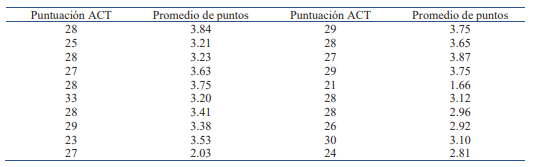

In [ ]:
def ejercicio3():
    print("\n" + "=" * 70)
    print("EJERCICIO 3")
    print("=" * 70)
    act = np.array([28, 25, 28, 27, 28, 33, 28, 29, 23, 27,
                     29, 28, 27, 29, 21, 28, 28, 26, 30, 24], dtype=float)
    gpa = np.array([3.84, 3.21, 3.23, 3.63, 3.75, 3.20, 3.41, 3.38, 3.53, 2.03,
                     3.75, 3.65, 3.87, 3.75, 1.66, 3.12, 2.96, 2.92, 3.10, 2.81])
 
    c1 = ajuste_polinomial(act, gpa, 1)
    e1 = error_cuadratico(gpa, evaluar_polinomio(c1, act))
    print(f"\nRecta de mínimos cuadrados: y = {texto_polinomio(c1)}")
    print(f"Error cuadrático E = {e1:.6f}")
 
    xs = np.linspace(act.min(), act.max(), 200)
    plt.figure(figsize=(8, 6))
    plt.scatter(act, gpa, color="crimson", zorder=3, label="Datos (20 estudiantes)")
    plt.plot(xs, evaluar_polinomio(c1, xs), color="steelblue",
             label=f"y = {c1[0]:.4f} + {c1[1]:.4f}·x")
    plt.title(f"Ejercicio 3 - Puntuación ACT vs Promedio de puntos (E={e1:.4f})")
    plt.xlabel("Puntuación ACT")
    plt.ylabel("Promedio de puntos (GPA)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTDIR}/ejercicio3.png", dpi=150)
    plt.show()
    plt.close()
    return c1, e1
 

4. El siguiente conjunto de datos, presentado al Subcomité Antimonopolio del Senado, muestra las
características comparativas de supervivencia durante un choque de automóviles de diferentes clases.
Encuentre la recta por mínimos cuadrados que aproxima estos datos (la tabla muestra el porcentaje de
vehículos que participaron en un accidente en los que la lesión más grave fue fatal o seria). 
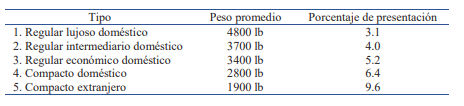

In [ ]:
def ejercicio4():
    print("\n" + "=" * 70)
    print("EJERCICIO 4")
    print("=" * 70)
    peso = np.array([4800, 3700, 3400, 2800, 1900], dtype=float)
    porcentaje = np.array([3.1, 4.0, 5.2, 6.4, 9.6])
 
    c1 = ajuste_polinomial(peso, porcentaje, 1)
    e1 = error_cuadratico(porcentaje, evaluar_polinomio(c1, peso))
    print(f"\nRecta de mínimos cuadrados: y = {texto_polinomio(c1)}")
    print(f"Error cuadrático E = {e1:.6f}")
 
    xs = np.linspace(peso.min(), peso.max(), 200)
    plt.figure(figsize=(8, 6))
    plt.scatter(peso, porcentaje, color="crimson", zorder=3, label="Datos (5 tipos de auto)")
    plt.plot(xs, evaluar_polinomio(c1, xs), color="steelblue",
             label=f"y = {c1[0]:.6f} {c1[1]:+.6f}·x")
    plt.title(f"Ejercicio 4 - Peso promedio vs % de siniestralidad (E={e1:.4f})")
    plt.xlabel("Peso promedio (lb)")
    plt.ylabel("Porcentaje de presentación (%)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTDIR}/ejercicio4.png", dpi=150)
    plt.show()
    plt.close()
    return c1, e1

## En todos los ejercicios debe graficar los puntos dados y la/s línea/s ajustadas. 

EJERCICIO 1

a) Grado 1: P(x) = -191.572419 +71.610244·x
   Error cuadrático E = 1058.838886

b) Grado 2: P(x) = 51.000789 -19.308604·x +8.217072·x^2
   Error cuadrático E = 551.656200

c) Grado 3: P(x) = 469.163265 -254.874783·x +51.560957·x^2 -2.606839·x^3
   Error cuadrático E = 518.383065

d) y = b·e^(a·x):  a = 0.368477, b = 24.776724
   y = 24.776724·e^(0.368477·x)
   Error cuadrático E = 821.005109

e) y = b·x^a:  a = 1.993285, b = 6.518682
   y = 6.518682·x^1.993285
   Error cuadrático E = 581.557273


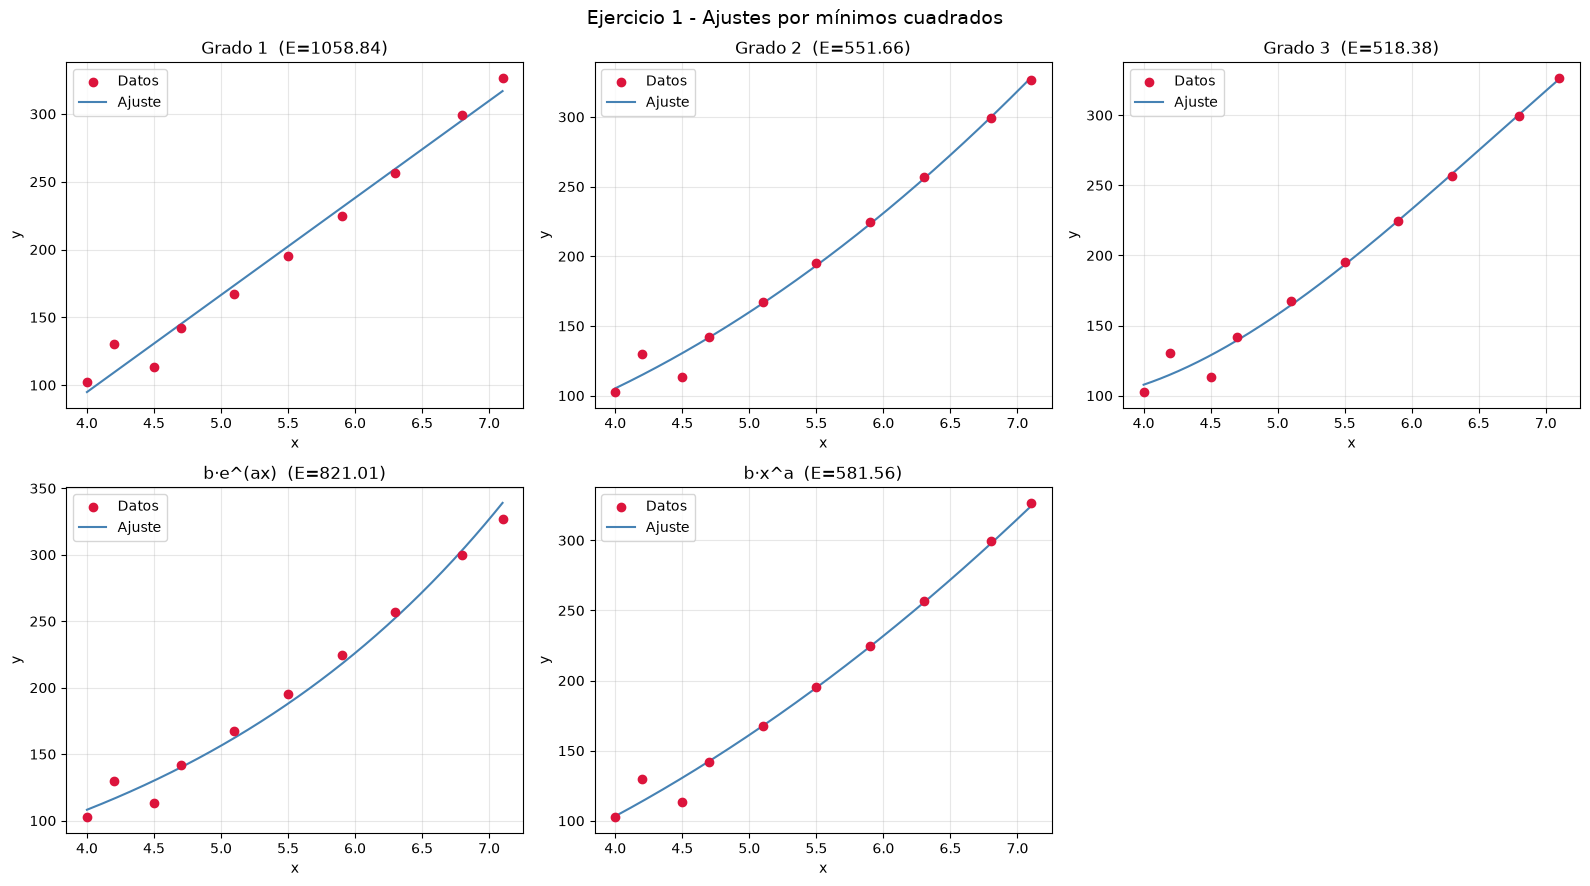


[Gráfica guardada en graficas/ejercicio1.png]

EJERCICIO 2

a) Grado 1: P(x) = -0.512457 +1.665540·x
   Error cuadrático E = 0.335590

b) Grado 2: P(x) = 0.085144 -0.311403·x +1.129424·x^2
   Error cuadrático E = 0.002420

c) Grado 3: P(x) = -0.018401 +0.248386·x +0.402932·x^2 +0.266208·x^3
   Error cuadrático E = 0.000005

d) y = b·e^(a·x):  a = 2.707295, b = 0.045707
   y = 0.045707·e^(2.707295·x)
   Error cuadrático E = 1.075049

e) y = b·x^a:  a = 1.872009, b = 0.950156
   y = 0.950156·x^1.872009
   Error cuadrático E = 0.054477


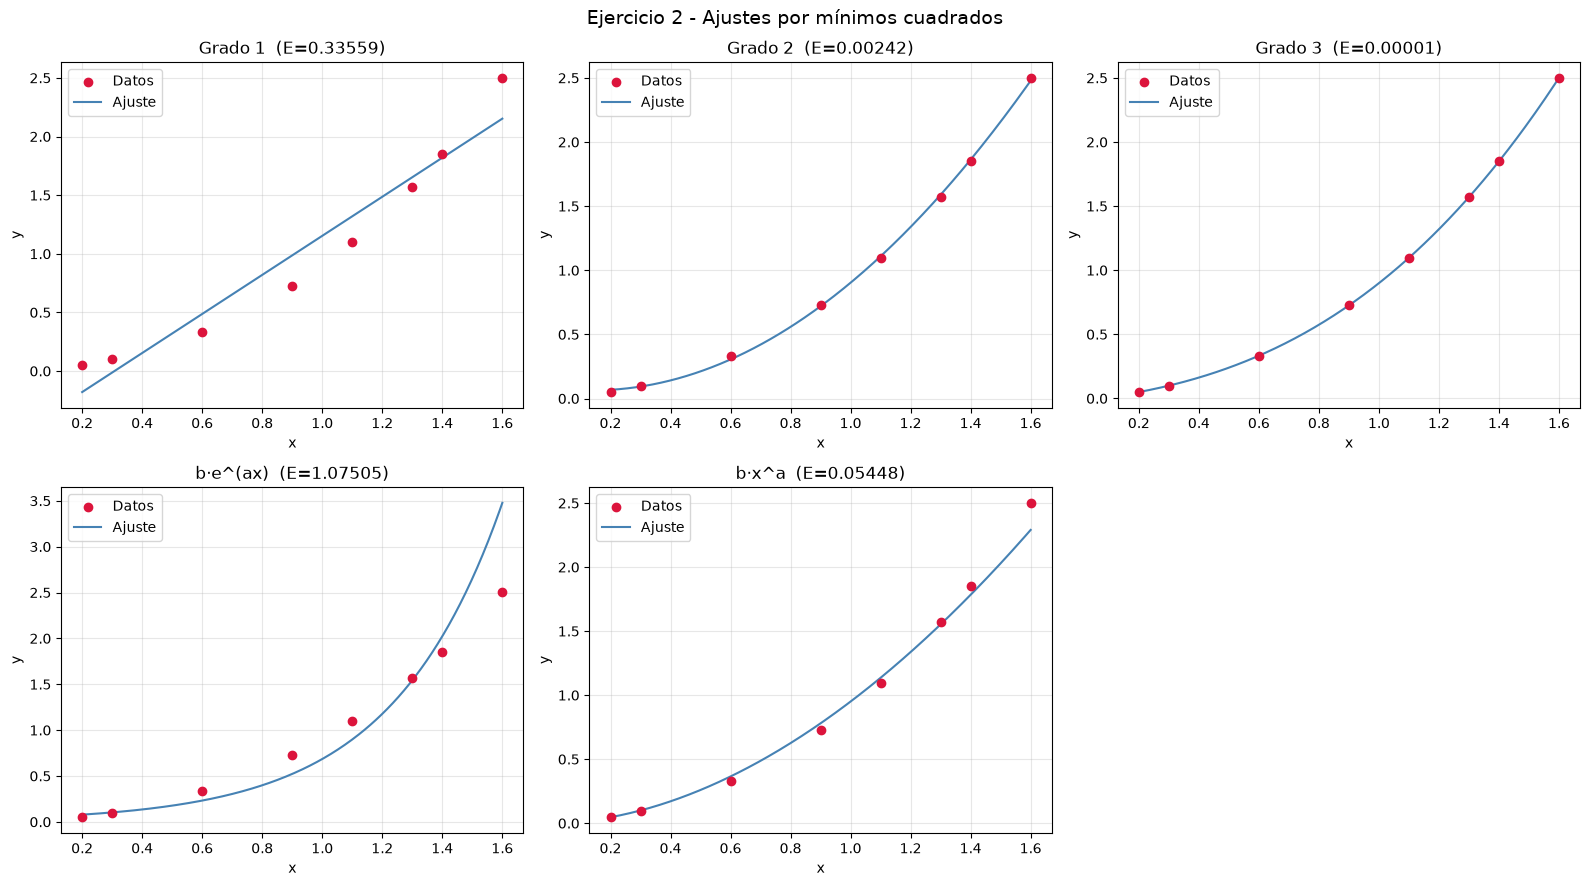


[Gráfica guardada en graficas/ejercicio2.png]

EJERCICIO 3

Recta de mínimos cuadrados: y = 0.486576 +0.100858·x
Error cuadrático E = 5.048706


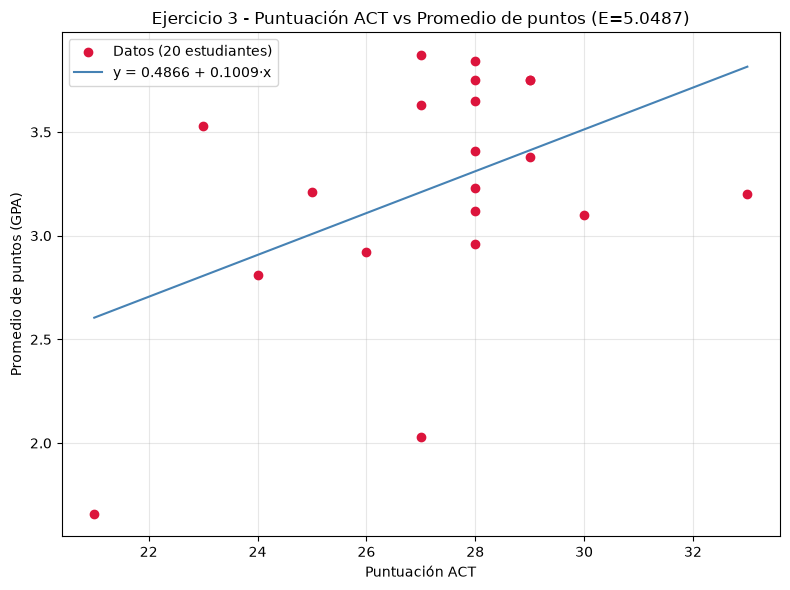

[Gráfica guardada en graficas/ejercicio3.png]

EJERCICIO 4

Recta de mínimos cuadrados: y = 13.146500 -0.002255·x
Error cuadrático E = 2.059136


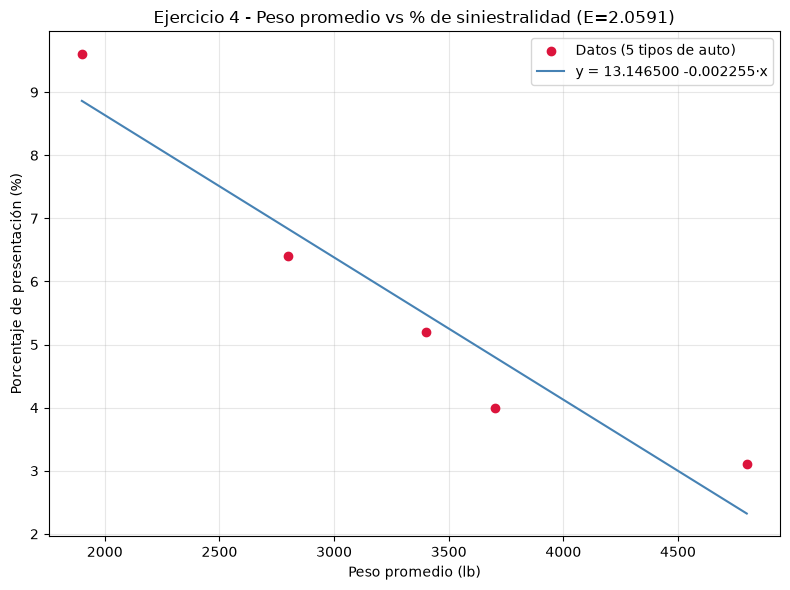

[Gráfica guardada en graficas/ejercicio4.png]


In [ ]:

if __name__ == "__main__":
    ejercicio1()
    ejercicio2()
    ejercicio3()
    ejercicio4()
